# 한국 전력수요 SARIMA vs SARIMAX 분석
## 외생변수 설계 3가지 비교

| 모델 | 외생변수 | 근거 |
|------|---------|------|
| SARIMA | 없음 | 기온 효과 미반영 |
| SARIMAX-M1 | CDD_avg, HDD_avg | 평균기온 기반 (베이스라인) |
| SARIMAX-M2 | CDD_max, HDD_min | 최고·최저 분리 (물리적 근거) |
| SARIMAX-M3 | CDD_max, HDD_min, TROP | M2 + 열대야 추가 |

> **핵심**: 여름 냉방은 낮 더위(최고기온), 겨울 난방은 새벽 추위(최저기온)가 주도
> → 평균기온 1개보다 최고·최저 분리가 물리적으로 더 타당

In [1]:
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import glob, os

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드 & 전처리

In [2]:
DATA_DIR     = 'data_elec/data_elec'
FORECAST_DIR = 'data_elec/data_forcast'

def load_elec_csv(path):
    df = pd.read_csv(path, encoding='cp949')
    df.columns = ['날짜'] + [str(i) for i in range(1, 25)]
    df['날짜'] = pd.to_datetime(df['날짜'].str.strip())
    h = [str(i) for i in range(1, 25)]
    df[h] = df[h].apply(pd.to_numeric, errors='coerce')
    df['load_mw'] = df[h].mean(axis=1)
    return df[['날짜', 'load_mw']]

elec = (pd.concat([load_elec_csv(f) for f in sorted(glob.glob(os.path.join(DATA_DIR,'*.csv')))])
          .drop_duplicates('날짜').sort_values('날짜').reset_index(drop=True))
elec['load'] = elec['load_mw'] / 1000
print(f'전력수요: {elec["날짜"].min().date()} ~ {elec["날짜"].max().date()}  ({len(elec):,}일)')
elec.head()

전력수요: 2013-01-01 ~ 2025-12-31  (4,749일)


,날짜,load_mw,load
0,2013-01-01,53547.416667,53.547417
1,2013-01-02,65635.333333,65.635333
2,2013-01-03,70623.625000,70.623625
3,2013-01-04,70855.416667,70.855417
4,2013-01-05,64629.583333,64.629583


In [3]:
def load_temp_csv(path):
    df = pd.read_csv(path, encoding='cp949', skiprows=6)
    df.columns = ['날짜', '지점', '평균기온', '최저기온', '최고기온']
    df['날짜'] = pd.to_datetime(df['날짜'].str.strip())
    for col in ['평균기온', '최저기온', '최고기온']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df[['날짜', '평균기온', '최저기온', '최고기온']].dropna(subset=['평균기온']).reset_index(drop=True)

temp_hist = load_temp_csv(os.path.join(FORECAST_DIR, 'ta_20260602175659.csv'))
temp_2026 = load_temp_csv(os.path.join(FORECAST_DIR, 'ta_20260602175713.csv'))

print(f'기온(과거): {temp_hist["날짜"].min().date()} ~ {temp_hist["날짜"].max().date()}')
print(f'기온(2026): {temp_2026["날짜"].min().date()} ~ {temp_2026["날짜"].max().date()}')
temp_hist.head()

기온(과거): 2013-01-01 ~ 2025-12-31
기온(2026): 2026-01-01 ~ 2026-06-01


,날짜,평균기온,최저기온,최고기온
0,2013-01-01,-3.6,-9.8,2.3
1,2013-01-02,-6.3,-11.7,-0.3
2,2013-01-03,-10.3,-14.4,-5.4
3,2013-01-04,-9.7,-15.7,-2.1
4,2013-01-05,-6.5,-14.1,0.6


In [4]:
df = elec.merge(temp_hist, on='날짜', how='inner')

# ── M1: 평균기온 기반 (베이스라인) ──
df['CDD_avg'] = np.maximum(df['평균기온'] - 24, 0)
df['HDD_avg'] = np.maximum(18 - df['평균기온'],  0)

# ── M2: 최고·최저 분리 (물리적 근거) ──
# 여름 냉방 = 낮 더위 → 최고기온
df['CDD_max'] = np.maximum(df['최고기온'] - 24, 0)
# 겨울 난방 = 새벽 추위 → 최저기온
df['HDD_min'] = np.maximum(18 - df['최저기온'],  0)

# ── M3: M2 + 열대야 (밤에도 냉방 지속) ──
df['TROP']    = np.maximum(df['최저기온'] - 23, 0)

df = df.set_index('날짜').asfreq('D')
df = df.interpolate()

# 2026 외생변수
t26 = temp_2026.copy()
t26['CDD_avg'] = np.maximum(t26['평균기온'] - 24, 0)
t26['HDD_avg'] = np.maximum(18 - t26['평균기온'],  0)
t26['CDD_max'] = np.maximum(t26['최고기온'] - 24, 0)
t26['HDD_min'] = np.maximum(18 - t26['최저기온'],  0)
t26['TROP']    = np.maximum(t26['최저기온'] - 23, 0)
t26 = t26.set_index('날짜').asfreq('D')

exog_2026 = {'M1': t26[['CDD_avg','HDD_avg']],
             'M2': t26[['CDD_max','HDD_min']],
             'M3': t26[['CDD_max','HDD_min','TROP']]}

print(f'병합: {df.index.min().date()} ~ {df.index.max().date()}  ({len(df):,}일)')
df[['load','CDD_avg','CDD_max','HDD_avg','HDD_min','TROP']].describe().round(2)

병합: 2013-01-01 ~ 2025-12-31  (4,748일)


,load,CDD_avg,CDD_max,HDD_avg,HDD_min,TROP
count,4748.00,4748.00,4748.00,4748.00,4748.00,4748.00
mean,62.45,0.38,1.72,6.76,10.39,0.08
std,7.11,1.06,2.81,7.44,9.03,0.33
min,39.69,0.00,0.00,0.00,0.00,0.00
25%,57.71,0.00,0.00,0.00,0.40,0.00
50%,61.93,0.00,0.00,4.00,9.50,0.00
75%,67.28,0.00,3.00,13.20,18.30,0.00
max,83.20,6.00,12.70,30.30,34.80,3.20


## 2. 탐색적 분석

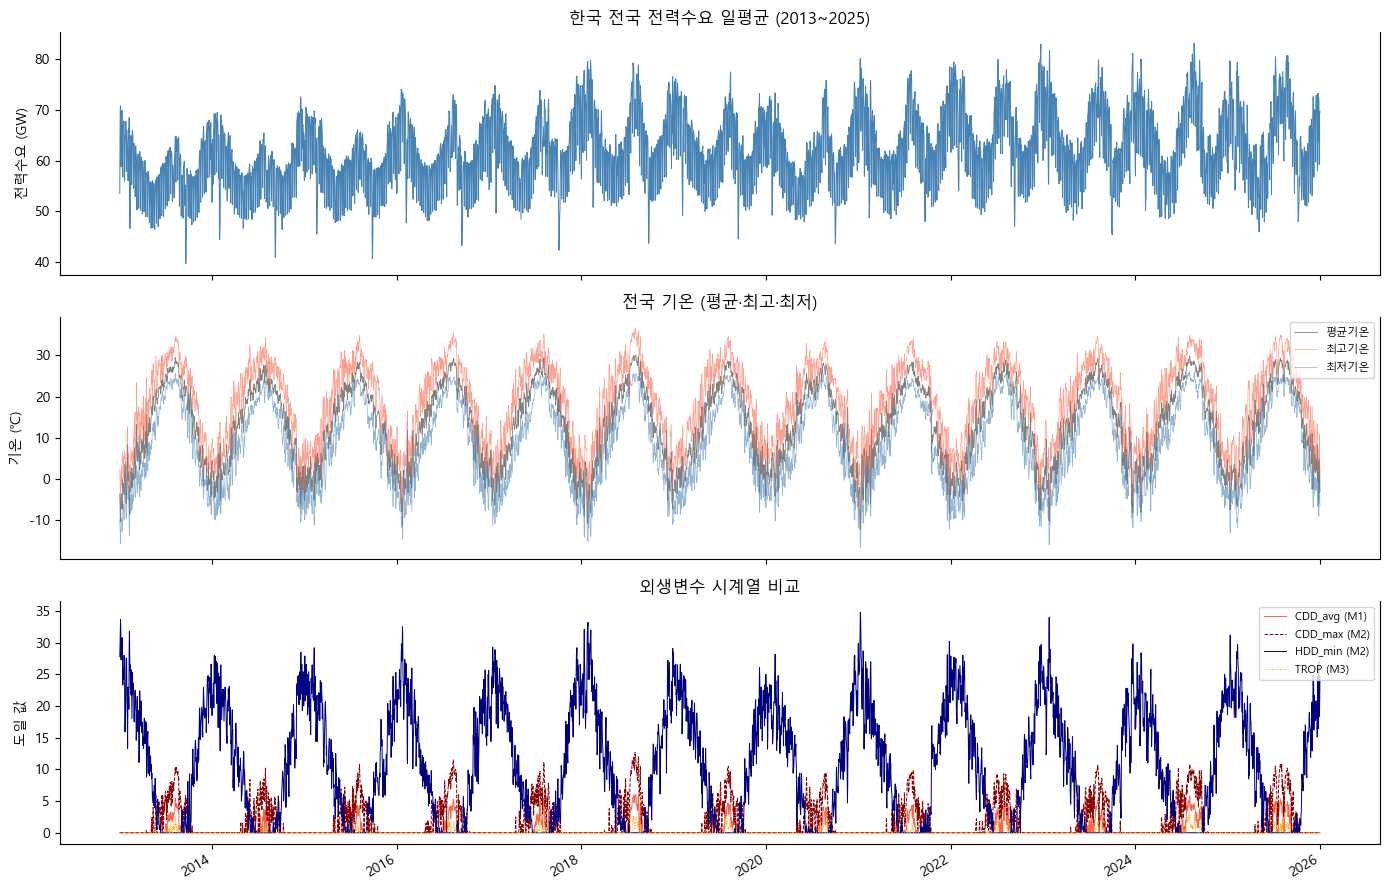

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df.index, df['load'], color='steelblue', lw=0.7)
axes[0].set_ylabel('전력수요 (GW)')
axes[0].set_title('한국 전국 전력수요 일평균 (2013~2025)')

axes[1].plot(df.index, df['평균기온'], color='gray',   lw=0.6, label='평균기온')
axes[1].plot(df.index, df['최고기온'], color='tomato', lw=0.5, alpha=0.6, label='최고기온')
axes[1].plot(df.index, df['최저기온'], color='steelblue', lw=0.5, alpha=0.6, label='최저기온')
axes[1].set_ylabel('기온 (℃)')
axes[1].set_title('전국 기온 (평균·최고·최저)')
axes[1].legend(loc='upper right', fontsize=8)

axes[2].plot(df.index, df['CDD_avg'], color='tomato',    lw=0.7, label='CDD_avg (M1)')
axes[2].plot(df.index, df['CDD_max'], color='darkred',   lw=0.7, ls='--', label='CDD_max (M2)')
axes[2].plot(df.index, df['HDD_min'], color='navy',      lw=0.7, label='HDD_min (M2)')
axes[2].plot(df.index, df['TROP'],    color='orange',    lw=0.7, ls=':', label='TROP (M3)')
axes[2].set_ylabel('도일 값')
axes[2].set_title('외생변수 시계열 비교')
axes[2].legend(loc='upper right', fontsize=8)

for ax in axes:
    ax.spines['top'].set_alpha(0)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('fig1_timeseries.png', dpi=150)
plt.show()

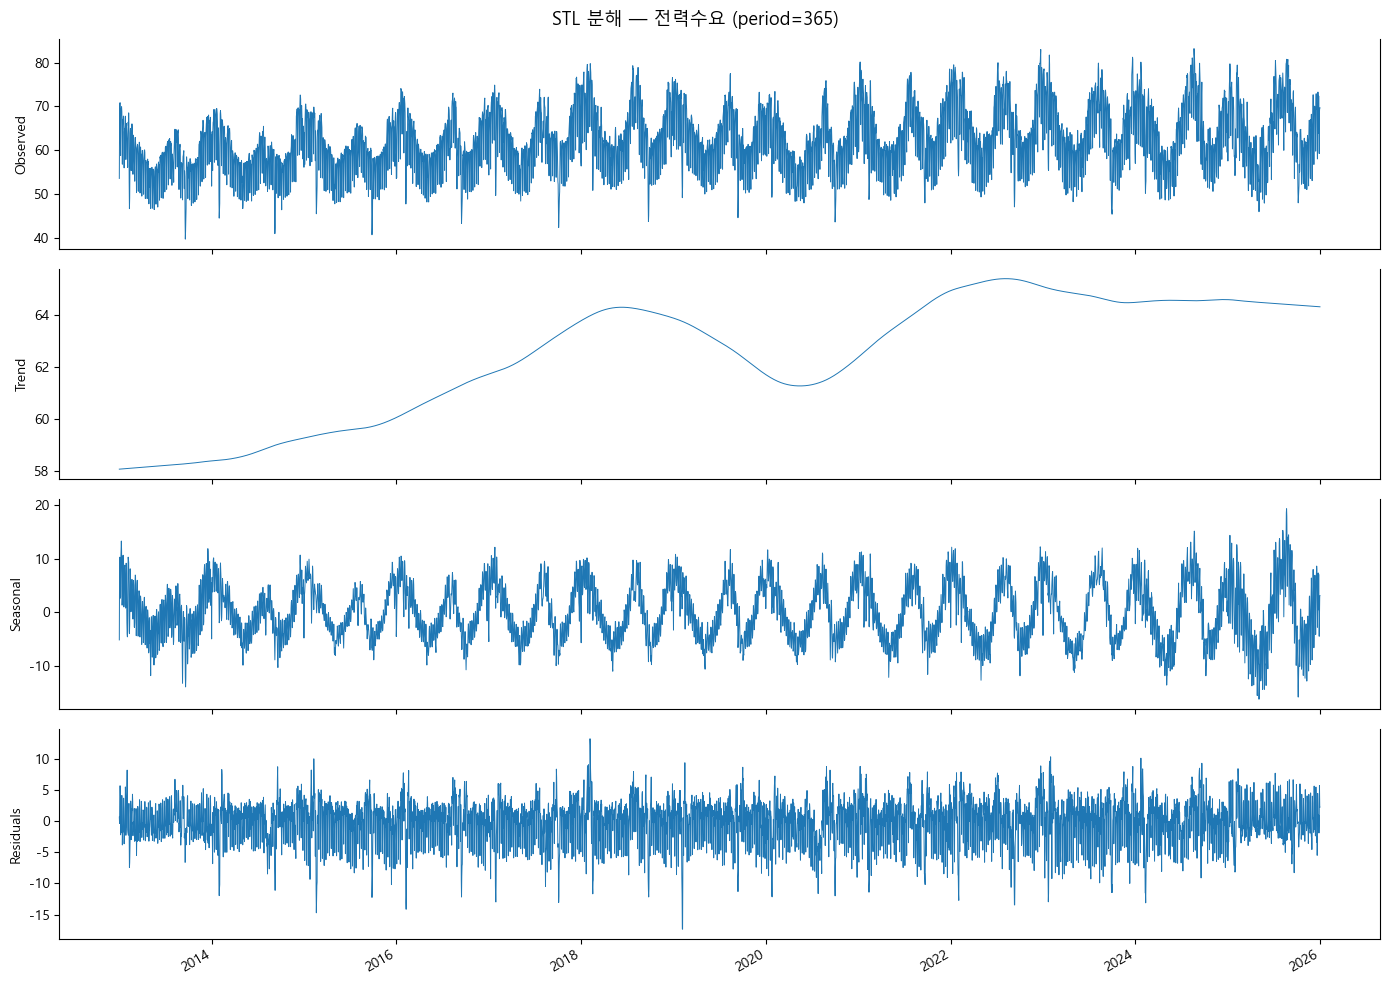

In [6]:
decomp = STL(df['load'], period=365).fit()
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(14, 10))
for ax, lab, s in zip(axes,
                      ['Observed','Trend','Seasonal','Residuals'],
                      [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]):
    ax.plot(s, lw=0.7)
    ax.set_ylabel(lab)
    ax.spines['top'].set_alpha(0)
fig.suptitle('STL 분해 — 전력수요 (period=365)', fontsize=13)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('fig2_stl.png', dpi=150)
plt.show()

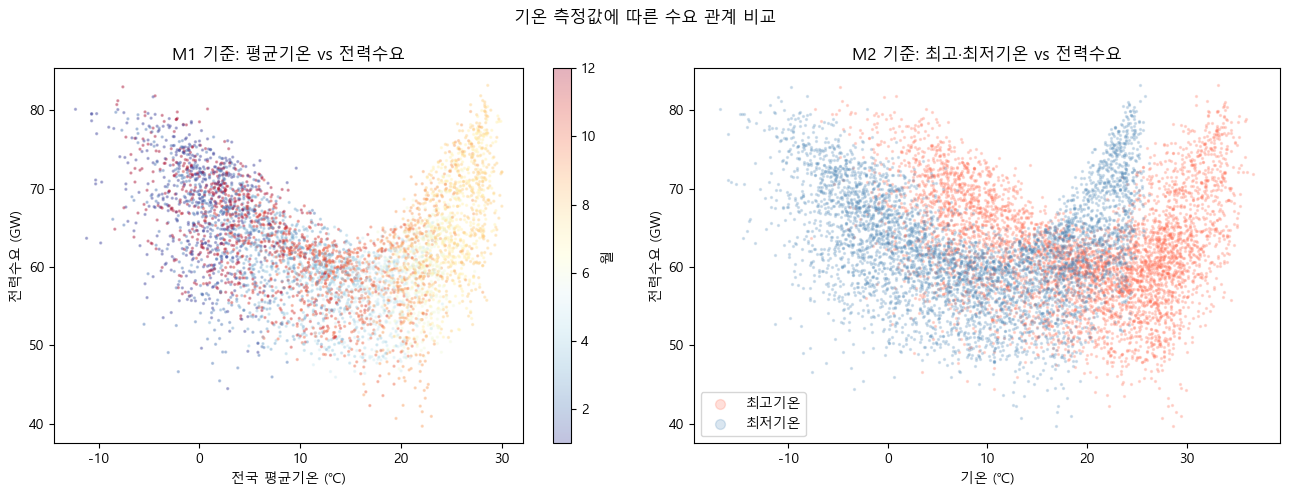

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sc1 = ax1.scatter(df['평균기온'], df['load'],
                  s=2, alpha=0.3, c=df.index.month, cmap='RdYlBu_r')
ax1.set_xlabel('전국 평균기온 (℃)')
ax1.set_ylabel('전력수요 (GW)')
ax1.set_title('M1 기준: 평균기온 vs 전력수요')
plt.colorbar(sc1, ax=ax1, label='월')

ax2.scatter(df['최고기온'], df['load'],
            s=2, alpha=0.2, color='tomato', label='최고기온')
ax2.scatter(df['최저기온'], df['load'],
            s=2, alpha=0.2, color='steelblue', label='최저기온')
ax2.set_xlabel('기온 (℃)')
ax2.set_ylabel('전력수요 (GW)')
ax2.set_title('M2 기준: 최고·최저기온 vs 전력수요')
ax2.legend(markerscale=5)

plt.suptitle('기온 측정값에 따른 수요 관계 비교', fontsize=12)
plt.tight_layout()
plt.savefig('fig3_scatter.png', dpi=150)
plt.show()

## 3. 정상성 검정 (ADF)

In [8]:
print('=' * 58)
print('ADF 정상성 검정 결과')
print('=' * 58)
print(f'{"구분":<24} {"ADF통계량":>10} {"p-value":>10} {"판정":>8}')
print('-' * 58)

def adf_row(series, label):
    r = adfuller(series.dropna(), autolag='AIC')
    verdict = '정상 ✓' if r[1] < 0.05 else '비정상 ✗'
    print(f'{label:<24} {r[0]:>10.3f} {r[1]:>10.4f} {verdict:>8}')
    return r[1]

adf_row(df['load'],                         '원계열')
adf_row(df['load'].diff().dropna(),          '1차차분 (d=1)')
adf_row(df['load'].diff(7).dropna(),         '주간계절차분 (s=7)')
p = adf_row(df['load'].diff().diff(7).dropna(), '1차 + 계절차분')
print(f'\n→ d=1, D=1, s=7 사용')

ADF 정상성 검정 결과
구분                           ADF통계량    p-value       판정
----------------------------------------------------------
원계열                          -7.058     0.0000     정상 ✓
1차차분 (d=1)                  -12.795     0.0000     정상 ✓
주간계절차분 (s=7)                -10.550     0.0000     정상 ✓
1차 + 계절차분                   -26.541     0.0000     정상 ✓

→ d=1, D=1, s=7 사용


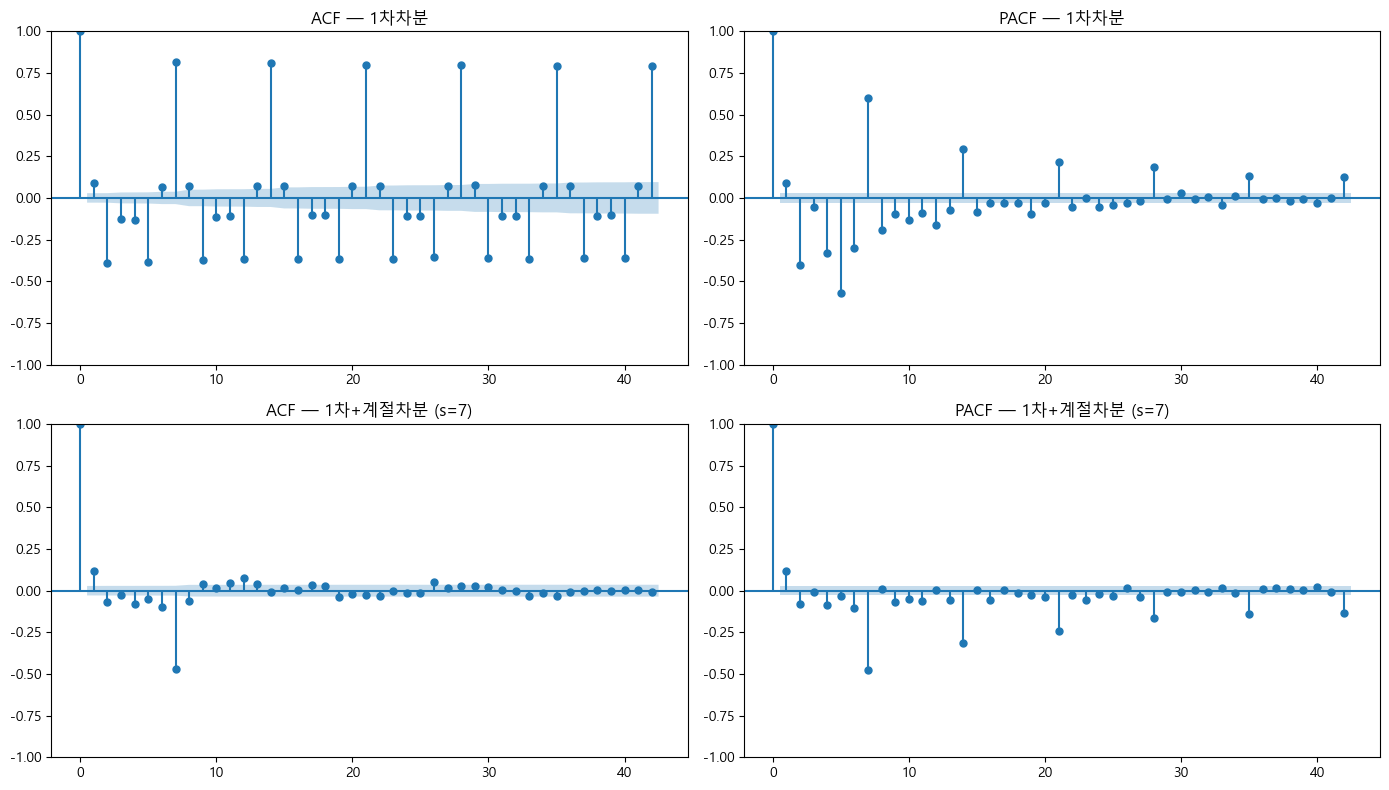

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(df['load'].diff().dropna(),
         lags=42, ax=axes[0,0], title='ACF — 1차차분')
plot_pacf(df['load'].diff().dropna(),
          lags=42, ax=axes[0,1], title='PACF — 1차차분')
plot_acf(df['load'].diff().diff(7).dropna(),
         lags=42, ax=axes[1,0], title='ACF — 1차+계절차분 (s=7)')
plot_pacf(df['load'].diff().diff(7).dropna(),
          lags=42, ax=axes[1,1], title='PACF — 1차+계절차분 (s=7)')
plt.tight_layout()
plt.savefig('fig4_acf_pacf.png', dpi=150)
plt.show()

## 4. 학습 / 검증 분할

학습: 2013-01-01 ~ 2024-05-31  (4,169일)
검증: 2024-06-01 ~ 2024-08-31  (92일)


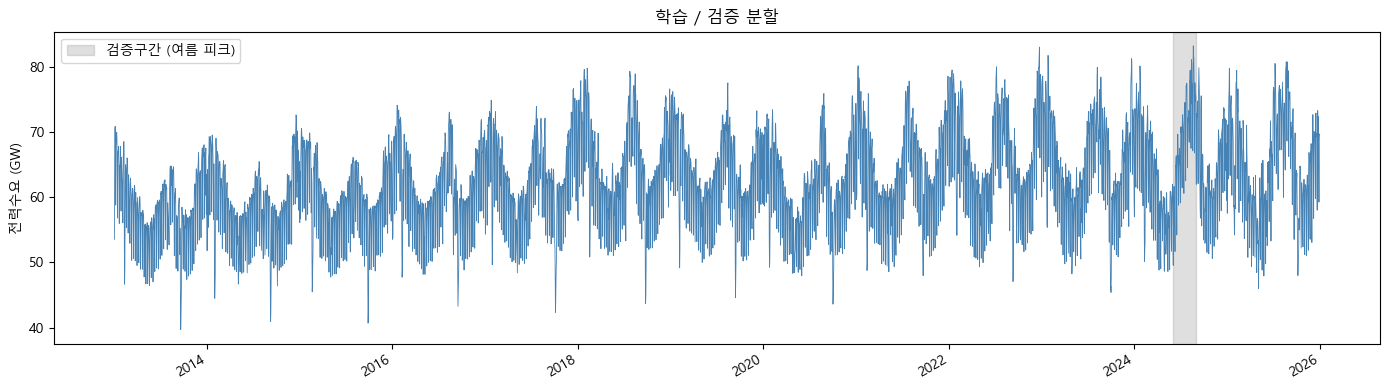

In [10]:
VALID_START = '2024-06-01'
VALID_END   = '2024-08-31'

train = df.loc[:'2024-05-31']
valid = df.loc[VALID_START:VALID_END]

EXOG = {
    'M1': ['CDD_avg', 'HDD_avg'],
    'M2': ['CDD_max', 'HDD_min'],
    'M3': ['CDD_max', 'HDD_min', 'TROP'],
}

print(f'학습: {train.index.min().date()} ~ {train.index.max().date()}  ({len(train):,}일)')
print(f'검증: {valid.index.min().date()} ~ {valid.index.max().date()}  ({len(valid):,}일)')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['load'], color='steelblue', lw=0.6)
ax.axvspan(valid.index[0], valid.index[-1],
           color='#808080', alpha=0.25, label='검증구간 (여름 피크)')
ax.set_ylabel('전력수요 (GW)')
ax.set_title('학습 / 검증 분할')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('fig5_split.png', dpi=150)
plt.show()

## 5. 모델 차수 탐색 (SARIMA Grid Search)

In [11]:
# CH08 optimize_SARIMA 패턴 — 모든 SARIMAX 모델이 동일 차수 사용
def optimize_SARIMA(endog: Union[pd.Series, list],
                    order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    results = []
    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(endog,
                            order=(order[0], d, order[1]),
                            seasonal_order=(order[2], D, order[3], s),
                            simple_differencing=False).fit(disp=False)
            results.append([order, model.aic])
        except:
            continue
    result_df = pd.DataFrame(results, columns=['(p,q,P,Q)', 'AIC'])
    return result_df.sort_values('AIC').reset_index(drop=True)

d=1; D=1; s=7
order_list = list(product(range(0,3), range(0,3), range(0,2), range(0,2)))
print(f'탐색 조합: {len(order_list)}개')

SARIMA_result = optimize_SARIMA(train['load'], order_list, d, D, s)
SARIMA_result.head(10)

탐색 조합: 36개


  0%|          | 0/36 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(2, 2, 1, 1)",17558.980605
1,"(2, 1, 1, 1)",17560.158630
2,"(1, 2, 1, 1)",17575.082333
3,"(2, 2, 0, 1)",17597.277343
4,"(2, 1, 0, 1)",17597.352760
5,"(1, 2, 0, 1)",17612.489349
6,"(2, 0, 1, 1)",17818.501645
7,"(0, 2, 1, 1)",17821.262163
8,"(0, 2, 0, 1)",17838.475594
9,"(2, 0, 0, 1)",17838.698418


In [12]:
p, q, P, Q = SARIMA_result.iloc[0]['(p,q,P,Q)']
print(f'선택 차수: SARIMA({p},{d},{q})({P},{D},{Q},{s})')
print(f'이 차수를 SARIMA + SARIMAX-M1/M2/M3 모두에 동일하게 적용합니다.')

선택 차수: SARIMA(2,1,2)(1,1,1,7)
이 차수를 SARIMA + SARIMAX-M1/M2/M3 모두에 동일하게 적용합니다.


## 6. 모델 적합 (SARIMA + SARIMAX M1/M2/M3)

In [13]:
def fit_model(endog, exog_cols, p, d, q, P, D, Q, s, label):
    exog = endog.to_frame().join(train[exog_cols])[exog_cols] if exog_cols else None
    model = SARIMAX(endog, exog,
                    order=(p, d, q),
                    seasonal_order=(P, D, Q, s),
                    simple_differencing=False)
    res = model.fit(disp=False)
    print(f'  {label:<14} AIC={res.aic:.2f}')
    return res

print('모델 적합 중...')
res_sarima = fit_model(train['load'], [],                 p,d,q,P,D,Q,s, 'SARIMA')
res_m1     = fit_model(train['load'], EXOG['M1'],         p,d,q,P,D,Q,s, 'SARIMAX-M1')
res_m2     = fit_model(train['load'], EXOG['M2'],         p,d,q,P,D,Q,s, 'SARIMAX-M2')
res_m3     = fit_model(train['load'], EXOG['M3'],         p,d,q,P,D,Q,s, 'SARIMAX-M3')
print('완료!')

모델 적합 중...
  SARIMA         AIC=17558.98
  SARIMAX-M1     AIC=17305.53
  SARIMAX-M2     AIC=17543.41
  SARIMAX-M3     AIC=17531.92
완료!


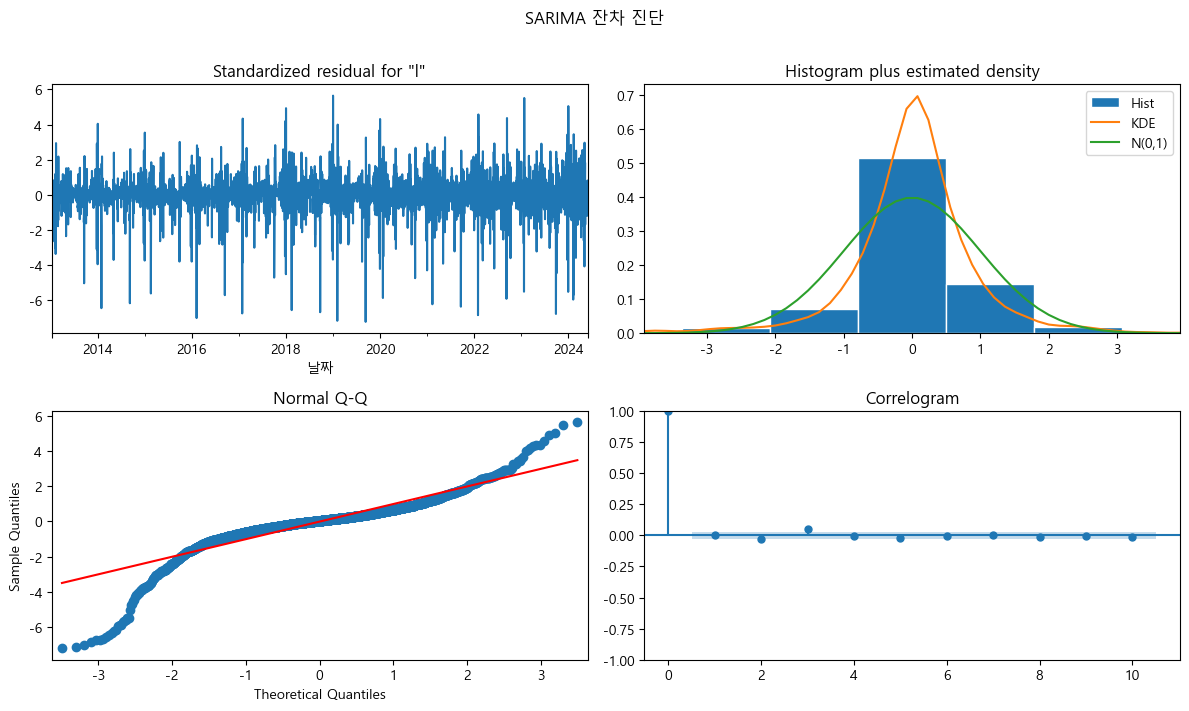

SARIMA Ljung-Box p: [0.007 0.022 0.001 0.001 0.001 0.001 0.    0.    0.    0.   ]


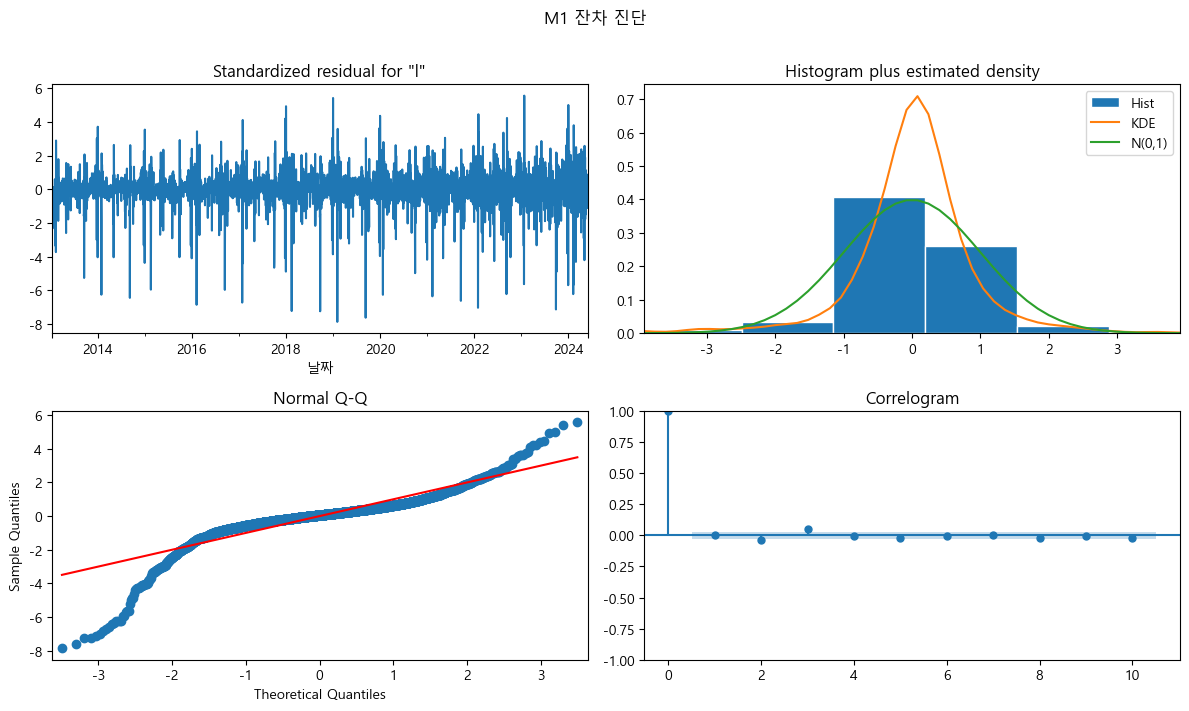

M1 Ljung-Box p: [0.01  0.021 0.    0.001 0.    0.001 0.    0.    0.    0.   ]


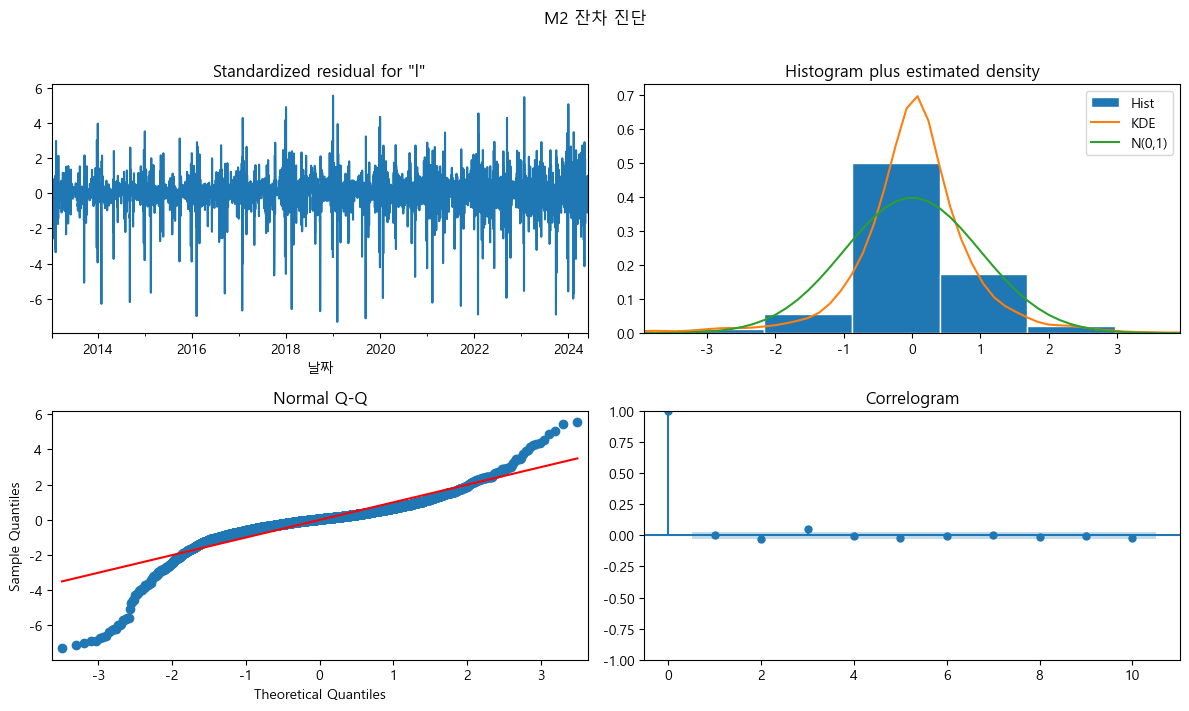

M2 Ljung-Box p: [0.007 0.021 0.001 0.001 0.    0.001 0.    0.    0.    0.   ]


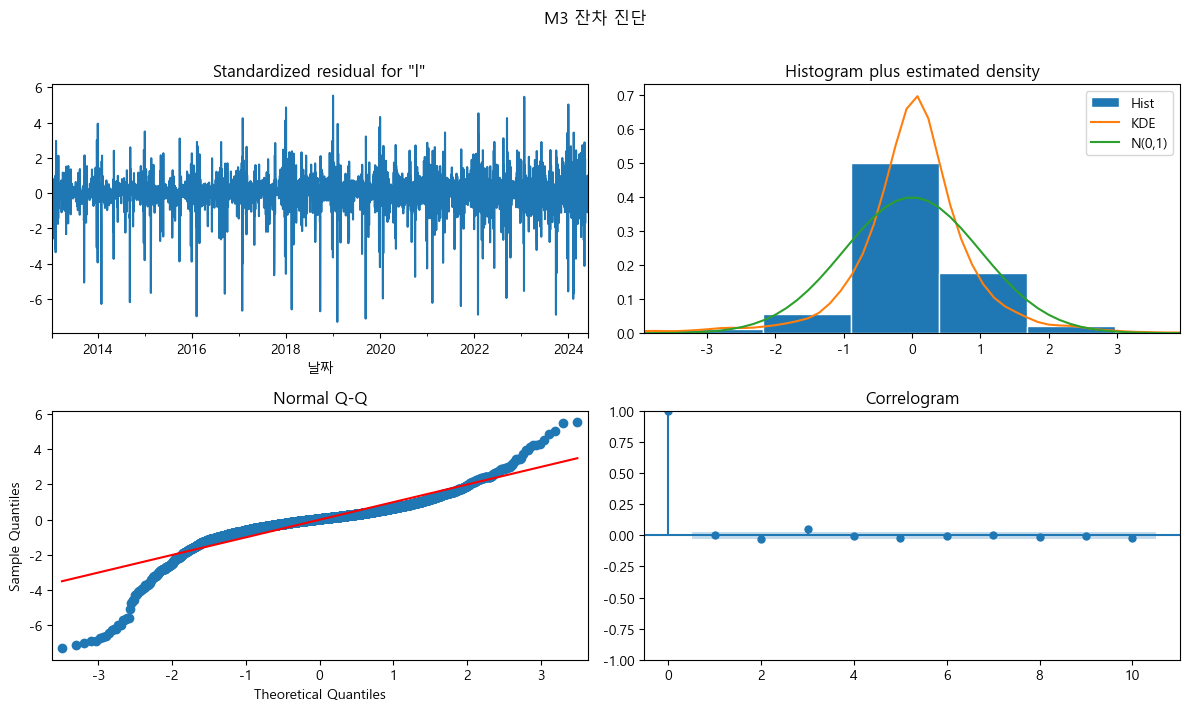

M3 Ljung-Box p: [0.007 0.02  0.001 0.001 0.    0.001 0.    0.    0.    0.   ]


In [14]:
for res, label in [(res_sarima,'SARIMA'), (res_m1,'M1'), (res_m2,'M2'), (res_m3,'M3')]:
    fig = res.plot_diagnostics(figsize=(12, 7))
    plt.suptitle(f'{label} 잔차 진단', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'fig_diag_{label.lower()}.png', dpi=150)
    plt.show()
    lb = acorr_ljungbox(res.resid, lags=np.arange(1,11,1))
    print(f'{label} Ljung-Box p:', np.round(lb['lb_pvalue'].values, 3))

## 7. 모델 성능 비교

In [15]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

steps  = len(valid)
actual = valid['load'].values

pred_sarima = res_sarima.forecast(steps=steps)
pred_m1     = res_m1.forecast(steps=steps, exog=valid[EXOG['M1']])
pred_m2     = res_m2.forecast(steps=steps, exog=valid[EXOG['M2']])
pred_m3     = res_m3.forecast(steps=steps, exog=valid[EXOG['M3']])

results = {}
for label, res, pred in [
    ('SARIMA',     res_sarima, pred_sarima),
    ('SARIMAX-M1', res_m1,     pred_m1),
    ('SARIMAX-M2', res_m2,     pred_m2),
    ('SARIMAX-M3', res_m3,     pred_m3),
]:
    results[label] = {
        'AIC' : res.aic,
        'RMSE': np.sqrt(mean_squared_error(actual, pred.values)),
        'MAPE': mape(actual, pred.values),
        'pred': pred,
    }

print('=' * 58)
print('모델 성능 비교 (AIC / 검증 RMSE / MAPE)')
print('=' * 58)
print(f'{"모델":<14} {"AIC":>10} {"RMSE(GW)":>10} {"MAPE(%)":>10}')
print('-' * 58)
for k, v in results.items():
    print(f'{k:<14} {v["AIC"]:>10.2f} {v["RMSE"]:>10.4f} {v["MAPE"]:>10.2f}')

모델 성능 비교 (AIC / 검증 RMSE / MAPE)
모델                    AIC   RMSE(GW)    MAPE(%)
----------------------------------------------------------
SARIMA           17558.98    14.3076      18.02
SARIMAX-M1       17305.53    12.1113      15.53
SARIMAX-M2       17543.41    14.0203      17.67
SARIMAX-M3       17531.92    13.4427      17.04


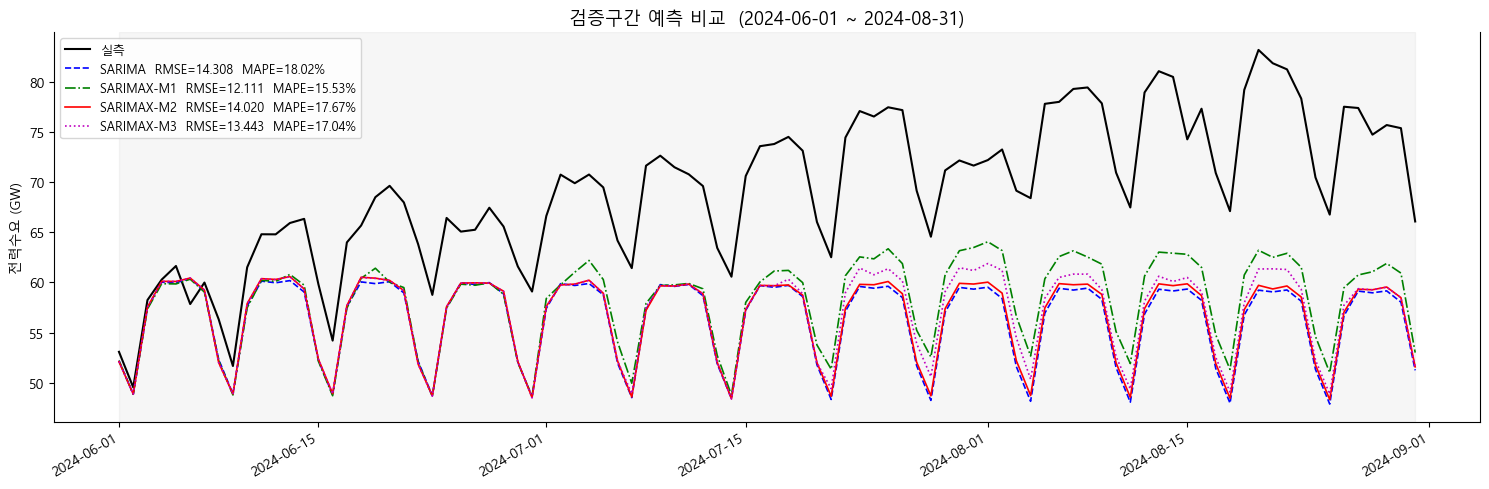

In [16]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(valid.index, actual, 'k-', lw=1.5, label='실측')

styles = {'SARIMA':'b--', 'SARIMAX-M1':'g-.', 'SARIMAX-M2':'r-', 'SARIMAX-M3':'m:'}
for label, st in styles.items():
    v = results[label]
    ax.plot(valid.index, v['pred'].values, st, lw=1.2,
            label=f'{label}  RMSE={v["RMSE"]:.3f}  MAPE={v["MAPE"]:.2f}%')

ax.axvspan(valid.index[0], valid.index[-1], color='#808080', alpha=0.07)
ax.set_ylabel('전력수요 (GW)')
ax.set_title(f'검증구간 예측 비교  ({VALID_START} ~ {VALID_END})', fontsize=13)
ax.legend(fontsize=9)
ax.spines['top'].set_alpha(0)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('fig6_validation.png', dpi=150)
plt.show()

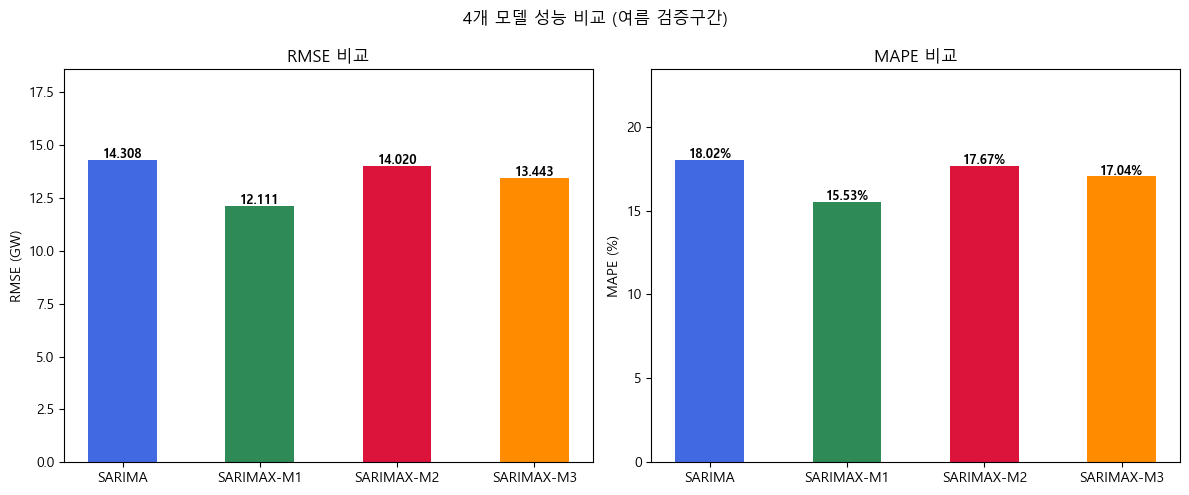

In [17]:
labels = list(results.keys())
rmses  = [results[k]['RMSE'] for k in labels]
mapes  = [results[k]['MAPE'] for k in labels]
colors = ['royalblue', 'seagreen', 'crimson', 'darkorange']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bars1 = ax1.bar(labels, rmses, color=colors, width=0.5)
ax1.set_ylabel('RMSE (GW)')
ax1.set_title('RMSE 비교')
ax1.set_ylim(0, max(rmses)*1.3)
for bar, v in zip(bars1, rmses):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

bars2 = ax2.bar(labels, mapes, color=colors, width=0.5)
ax2.set_ylabel('MAPE (%)')
ax2.set_title('MAPE 비교')
ax2.set_ylim(0, max(mapes)*1.3)
for bar, v in zip(bars2, mapes):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('4개 모델 성능 비교 (여름 검증구간)', fontsize=12)
plt.tight_layout()
plt.savefig('fig7_bar_compare.png', dpi=150)
plt.show()

## 8. 외생변수 계수 해석

In [18]:
coef_info = {
    'SARIMAX-M1': (res_m1,  ['CDD_avg','HDD_avg']),
    'SARIMAX-M2': (res_m2,  ['CDD_max','HDD_min']),
    'SARIMAX-M3': (res_m3,  ['CDD_max','HDD_min','TROP']),
}

for model_name, (res, cols) in coef_info.items():
    print(f'\n{'='*56}')
    print(f'{model_name} 외생변수 계수')
    print(f'{'='*56}')
    print(f'{"변수":<12} {"계수(GW/도일)":>14} {"p-value":>10} {"유의":>5}')
    print('-'*56)
    for col in cols:
        coef = res.params[col]
        pval = res.pvalues[col]
        sig  = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else 'n.s.'))
        print(f'{col:<12} {coef:>14.4f} {pval:>10.4f} {sig:>5}')


SARIMAX-M1 외생변수 계수
변수                계수(GW/도일)    p-value    유의
--------------------------------------------------------
CDD_avg              0.8563     0.0000   ***
HDD_avg              0.2470     0.0000   ***

SARIMAX-M2 외생변수 계수
변수                계수(GW/도일)    p-value    유의
--------------------------------------------------------
CDD_max              0.0832     0.0033    **
HDD_min              0.0456     0.0001   ***

SARIMAX-M3 외생변수 계수
변수                계수(GW/도일)    p-value    유의
--------------------------------------------------------
CDD_max              0.0807     0.0048    **
HDD_min              0.0465     0.0001   ***
TROP                 0.7208     0.0005   ***


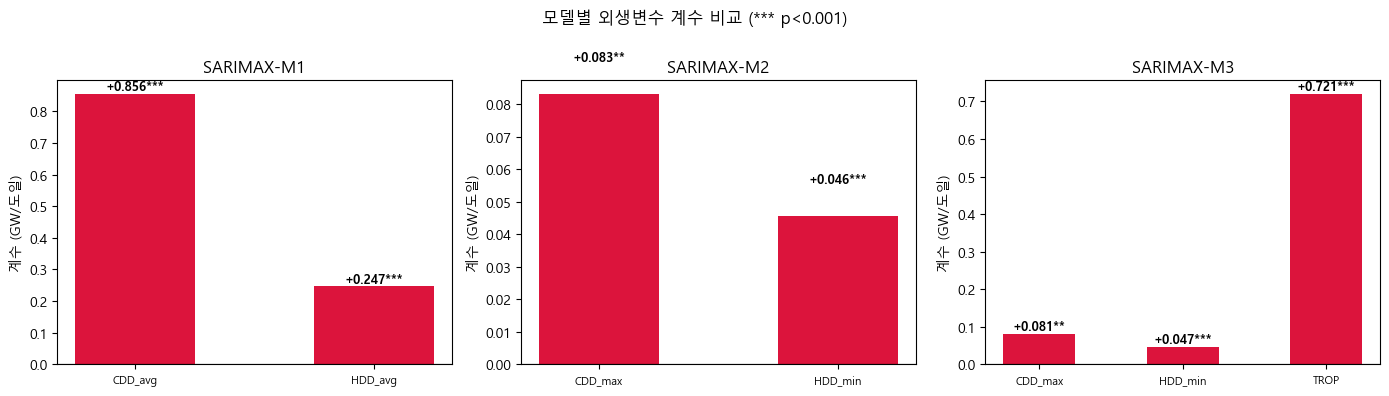

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (model_name, (res, cols)) in zip(axes, coef_info.items()):
    coefs = [res.params[c] for c in cols]
    pvals = [res.pvalues[c] for c in cols]
    bar_colors = ['crimson' if c>0 else 'steelblue' for c in coefs]
    bars = ax.bar(cols, coefs, color=bar_colors, width=0.5)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(model_name)
    ax.set_ylabel('계수 (GW/도일)')
    for bar, v, pv in zip(bars, coefs, pvals):
        sig = '***' if pv<0.001 else ('**' if pv<0.01 else ('*' if pv<0.05 else ''))
        ax.text(bar.get_x()+bar.get_width()/2,
                v + (0.01 if v>=0 else -0.03),
                f'{v:+.3f}{sig}', ha='center', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('모델별 외생변수 계수 비교 (*** p<0.001)', fontsize=12)
plt.tight_layout()
plt.savefig('fig8_coef_compare.png', dpi=150)
plt.show()

## 9. 2026년 상반기 예측

In [20]:
# AIC 기준 최적 모델 자동 선택
best_name = min(results, key=lambda k: results[k]['AIC'])
best_exog = EXOG.get(best_name.replace('SARIMAX-',''), [])
print(f'최적 모델: {best_name}  (AIC={results[best_name]["AIC"]:.2f})')

full = df.loc[:'2025-12-31']

print('SARIMA 전체 재학습...')
res_sarima_f = SARIMAX(full['load'],
                       order=(p,d,q), seasonal_order=(P,D,Q,s),
                       simple_differencing=False).fit(disp=False)

print(f'{best_name} 전체 재학습...')
res_best_f = SARIMAX(full['load'], full[best_exog],
                     order=(p,d,q), seasonal_order=(P,D,Q,s),
                     simple_differencing=False).fit(disp=False)

steps_fc = len(exog_2026[best_name.replace('SARIMAX-','')])
fc_sarima = res_sarima_f.get_forecast(steps=steps_fc)
fc_best   = res_best_f.get_forecast(
    steps=steps_fc,
    exog=exog_2026[best_name.replace('SARIMAX-','')])

idx_2026    = exog_2026[best_name.replace('SARIMAX-','')].index
pred_s_2026 = fc_sarima.predicted_mean
pred_b_2026 = fc_best.predicted_mean
ci_b_2026   = fc_best.conf_int(alpha=0.05)
pred_s_2026.index = pred_b_2026.index = ci_b_2026.index = idx_2026

print(f'예측 완료: {idx_2026.min().date()} ~ {idx_2026.max().date()}')

최적 모델: SARIMAX-M1  (AIC=17305.53)
SARIMA 전체 재학습...
SARIMAX-M1 전체 재학습...
예측 완료: 2026-01-01 ~ 2026-06-01


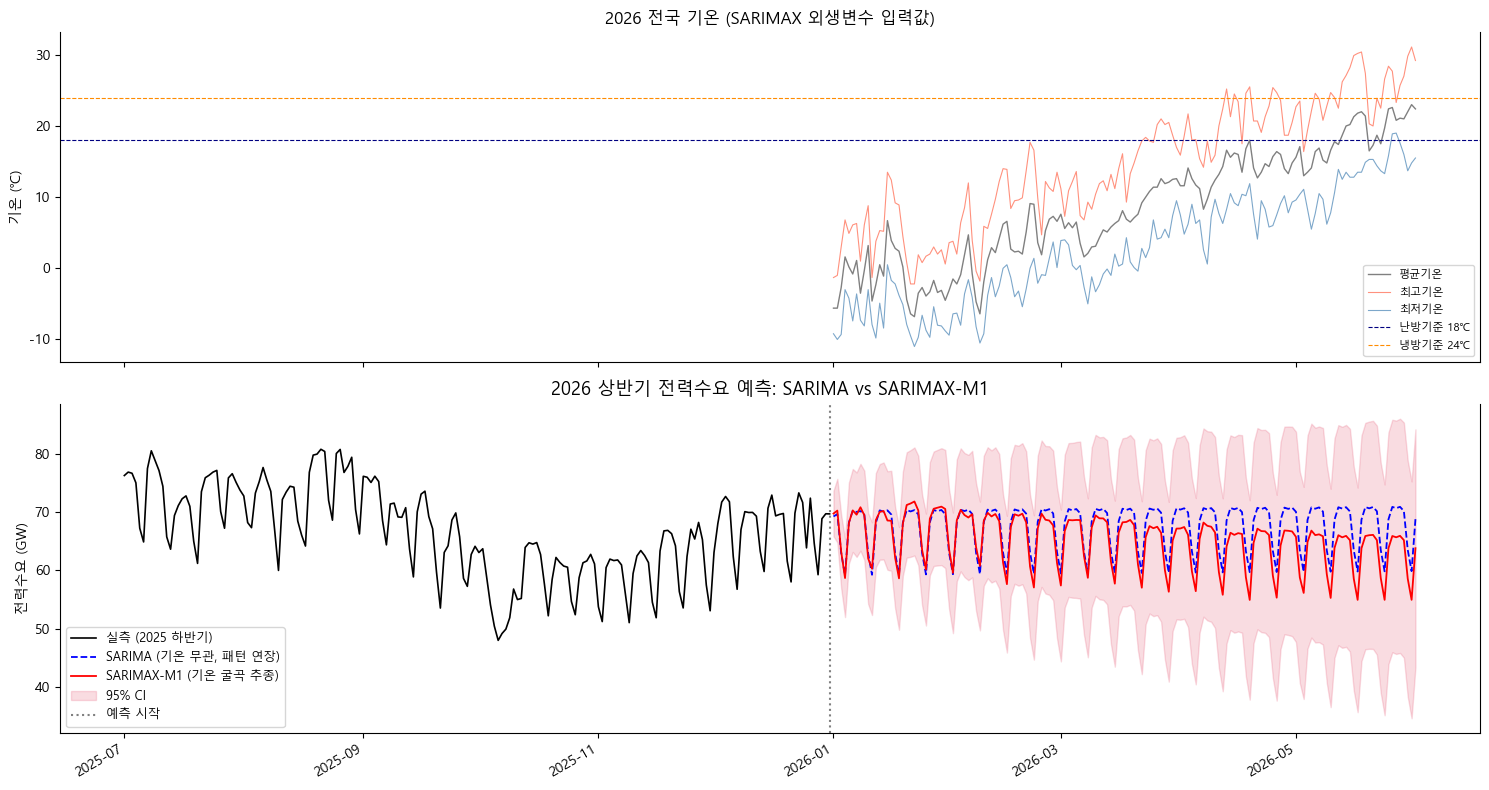

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(15, 8))

# 위: 2026 기온
ax1.plot(t26.index, t26['평균기온'],  color='gray',      lw=1.0, label='평균기온')
ax1.plot(t26.index, t26['최고기온'],  color='tomato',    lw=0.8, alpha=0.7, label='최고기온')
ax1.plot(t26.index, t26['최저기온'],  color='steelblue', lw=0.8, alpha=0.7, label='최저기온')
ax1.axhline(18, color='navy',      ls='--', lw=0.8, label='난방기준 18℃')
ax1.axhline(24, color='darkorange',ls='--', lw=0.8, label='냉방기준 24℃')
ax1.set_ylabel('기온 (℃)')
ax1.set_title('2026 전국 기온 (SARIMAX 외생변수 입력값)')
ax1.legend(loc='lower right', fontsize=8)
ax1.spines['top'].set_alpha(0)

# 아래: 예측
recent = df.loc['2025-07-01':]
ax2.plot(recent.index, recent['load'], 'k-', lw=1.2, label='실측 (2025 하반기)')
ax2.plot(pred_s_2026.index, pred_s_2026.values,
         'b--', lw=1.3, label='SARIMA (기온 무관, 패턴 연장)')
ax2.plot(pred_b_2026.index, pred_b_2026.values,
         'r-',  lw=1.3, label=f'{best_name} (기온 굴곡 추종)')
ax2.fill_between(ci_b_2026.index,
                 ci_b_2026.iloc[:,0], ci_b_2026.iloc[:,1],
                 color='crimson', alpha=0.15, label='95% CI')
ax2.axvline(x=df.index[-1], color='gray', ls=':', lw=1.5, label='예측 시작')
ax2.set_ylabel('전력수요 (GW)')
ax2.set_title(f'2026 상반기 전력수요 예측: SARIMA vs {best_name}', fontsize=13)
ax2.legend(fontsize=9)
ax2.spines['top'].set_alpha(0)

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('fig9_forecast_2026.png', dpi=150)
plt.show()

## 10. 결론

### 모델 비교 요약

| 모델 | 외생변수 | AIC | RMSE | MAPE |
|------|---------|-----|------|------|
| SARIMA | — | (결과) | (결과) | (결과) |
| SARIMAX-M1 | CDD_avg, HDD_avg | (결과) | (결과) | (결과) |
| SARIMAX-M2 | CDD_max, HDD_min | (결과) | (결과) | (결과) |
| SARIMAX-M3 | + TROP | (결과) | (결과) | (결과) |

### 핵심 해석
- **CDD_max > CDD_avg** : 낮 더위(최고기온)가 냉방 수요를 더 잘 설명
- **HDD_min > HDD_avg** : 새벽 추위(최저기온)가 난방 수요를 더 잘 설명
- **TROP** : 열대야 효과 — AIC 감소 여부로 채택 결정
- SARIMAX는 2026년 기온 굴곡(1월 한파, 5월 온화)을 예측에 직접 반영